In [17]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [5]:
df=pd.read_csv(r'C:\Users\vikes\Desktop\Mortgage_prediction-ML\notebook\mortgage_loan_dataset.csv')

In [6]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


In [7]:
df.columns

Index(['Gender', 'Age', 'Married', 'Education', 'Job', 'Employment Years',
       'Annual Income (USD)', 'Interest Rate', 'Down Payment (USD)',
       'Credit Score', 'Existing Monthly Debt (USD)', 'Area', 'Loans Repaid',
       'Max Loan Amount (USD)'],
      dtype='object')

In [9]:
# Debt to Income Ratio
df["Debt_to_Income_Ratio"] = (
    df["Existing Monthly Debt (USD)"] /
    df["Annual Income (USD)"]
)

# Down Payment Ratio
df["Down_Payment_Ratio"] = (
    df["Down Payment (USD)"] /
    df["Annual Income (USD)"]
)

# Experience to Age Ratio
df["Experience_Age_Ratio"] = (
    df["Employment Years"] /
    df["Age"]
)

# Income per Employment Year
df["Income_per_Employment_Year"] = np.where(
    df["Employment Years"] == 0,
    0,
    df["Annual Income (USD)"] / df["Employment Years"]
)

In [11]:
df.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD),Debt_to_Income_Ratio,Down_Payment_Ratio,Experience_Age_Ratio,Income_per_Employment_Year
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67,0.015246,0.757966,0.361111,10321.835385
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53,0.011682,0.672488,0.587302,1861.755405
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47,0.013751,0.170765,0.333333,6945.115455
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14,0.007796,0.520730,0.568627,3998.924138
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21,0.022863,0.548505,0.509434,3702.865926


In [10]:
df.columns

Index(['Gender', 'Age', 'Married', 'Education', 'Job', 'Employment Years',
       'Annual Income (USD)', 'Interest Rate', 'Down Payment (USD)',
       'Credit Score', 'Existing Monthly Debt (USD)', 'Area', 'Loans Repaid',
       'Max Loan Amount (USD)', 'Debt_to_Income_Ratio', 'Down_Payment_Ratio',
       'Experience_Age_Ratio', 'Income_per_Employment_Year'],
      dtype='object')

In [12]:
target = "Max Loan Amount (USD)"

In [13]:
X = df.drop(columns=[target])

y = df[target]

In [14]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (49990, 17)
y Shape : (49990,)


In [15]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Gender', 'Married', 'Education', 'Job', 'Area']

Numerical Features:
['Age', 'Employment Years', 'Annual Income (USD)', 'Interest Rate', 'Down Payment (USD)', 'Credit Score', 'Existing Monthly Debt (USD)', 'Loans Repaid', 'Debt_to_Income_Ratio', 'Down_Payment_Ratio', 'Experience_Age_Ratio', 'Income_per_Employment_Year']


In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None
            )
        )
    ]
)



preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

In [27]:
def evaluate_models(
    models,
    preprocessor,
    X_train,
    X_test,
    y_train,
    y_test
):

    results = []

    for model_name, model in models.items():

        # Create complete pipeline
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        # Train
        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)

        mse = mean_squared_error(y_test, y_pred)

        rmse = np.sqrt(mse)

        r2 = r2_score(y_test, y_pred)

        results.append(
            {
                "Model": model_name,
                "MAE": round(mae,2),
                "RMSE": round(rmse,2),
                "R2 Score": round(r2,4)
            }
        )

    results = pd.DataFrame(results)

    results = results.sort_values(
        by="R2 Score",
        ascending=False
    )

    return results

In [28]:
model_results = evaluate_models(
    models=models,
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

model_results

,Model,MAE,RMSE,R2 Score
8,Extra Trees,16746.33,23468.72,0.9943
5,Random Forest,17590.58,24379.80,0.9938
6,Gradient Boosting,18868.27,25357.16,0.9933
4,Decision Tree,29531.98,40707.34,0.9828
1,Lasso,48933.82,66708.30,0.9537
2,Ridge,48934.20,66708.62,0.9537
0,Linear Regression,49162.85,66877.50,0.9535
9,KNN,64195.89,84127.02,0.9264
7,AdaBoost,74833.53,92674.52,0.9107
3,ElasticNet,78571.53,105775.98,0.8837


In [31]:
from sklearn.pipeline import Pipeline

model_list = []
r2_list = []

for model_name, model in models.items():

    # Create pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Evaluation
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    # Store results
    model_list.append(model_name)
    r2_list.append(test_r2)

    # Print results
    print("=" * 50)
    print(f"Model : {model_name}")
    print("-" * 50)
    print(f"Train R² : {train_r2:.4f}")
    print(f"Test R²  : {test_r2:.4f}")
    print(f"Train RMSE : {train_rmse:.2f}")
    print(f"Test RMSE  : {test_rmse:.2f}")

Model : Linear Regression
--------------------------------------------------
Train R² : 0.9539
Test R²  : 0.9535
Train RMSE : 67255.48
Test RMSE  : 66877.50
Model : Lasso
--------------------------------------------------
Train R² : 0.9544
Test R²  : 0.9537
Train RMSE : 66925.41
Test RMSE  : 66708.30
Model : Ridge
--------------------------------------------------
Train R² : 0.9544
Test R²  : 0.9537
Train RMSE : 66925.42
Test RMSE  : 66708.62
Model : ElasticNet
--------------------------------------------------
Train R² : 0.8841
Test R²  : 0.8837
Train RMSE : 106680.27
Test RMSE  : 105775.98
Model : Decision Tree
--------------------------------------------------
Train R² : 1.0000
Test R²  : 0.9828
Train RMSE : 0.00
Test RMSE  : 40707.34
Model : Random Forest
--------------------------------------------------
Train R² : 0.9991
Test R²  : 0.9938
Train RMSE : 9218.72
Test RMSE  : 24379.80
Model : Gradient Boosting
--------------------------------------------------
Train R² : 0.9942
Test 

In [33]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
8,Extra Trees,0.994275
5,Random Forest,0.993822
6,Gradient Boosting,0.993317
4,Decision Tree,0.982777
1,Lasso,0.953748
2,Ridge,0.953747
0,Linear Regression,0.953513
9,KNN,0.926439
7,AdaBoost,0.910732
3,ElasticNet,0.883708


## EXAMPLE of how to train model one by one


In [40]:
lin_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lin_pipeline.fit(X_train, y_train)

y_pred = lin_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"Linear Regression R² Score: {r2:.4f}")

Linear Regression R² Score: 0.9535


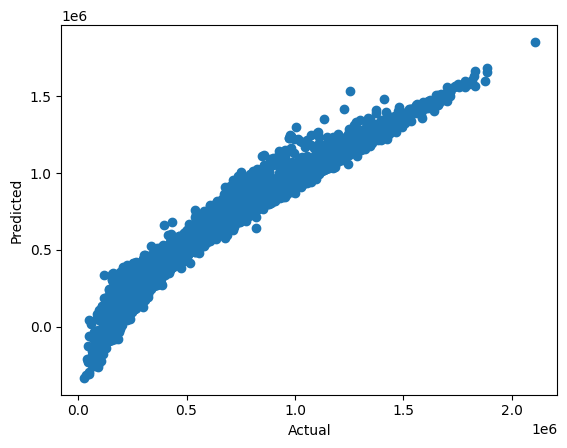

In [36]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

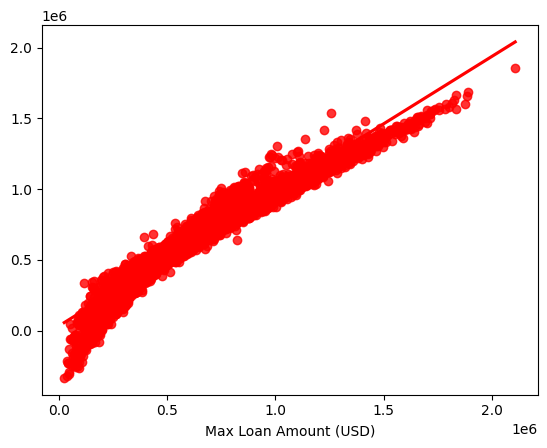

In [37]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [38]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})

In [39]:
pred_df

,Actual Value,Predicted Value,Difference
47831,1340679.04,1182848.0,157831.04
34682,676532.04,682496.0,-5963.96
47237,530134.23,562176.0,-32041.77
6705,508207.81,526208.0,-18000.19
33242,586542.14,707712.0,-121169.86
...,...,...,...
39079,1096648.46,1147648.0,-50999.54
24377,1098619.04,1102848.0,-4228.96
21100,796784.88,756992.0,39792.88
35885,1583370.50,1413888.0,169482.50
